# Descripción y análisis exploratorio de datos

**Materia:** Análisis de Series de Tiempo y Pronósticos (1C-2026)

**Grupo:** 9

**Integrantes:**

- Lucas Achaval - Email: lachavalrodriguez@estudiantes.unsam.edu.ar
- Marcos Achaval - Email: machavalrodriguez@unsam-bue.edu.ar

**Título del entregable:** Descripción y análisis exploratorio de datos

**Conjunto de datos original:** dataset propio de una estación meteorológica en un club náutico de Potrerillos (disponibles en [Windguru](https://www.windguru.cz/station/15338)).

## Descripción breve del conjunto de datos y su origen

Este conjunto de datos proviene de una estación meteorológica instalada en un club náutico en Potrerillos, Mendoza. La estación registra una observación por minuto con variables de viento mínimo, promedio y máximo, además de rachas, dirección, temperatura, humedad relativa y presión atmosférica.

El archivo cubre desde 2025-08-01 hasta 2026-04-14. Son mediciones reales en un entorno de montaña con un ciclo diario de viento bien marcado.

## Problema o pregunta a resolver

Potrerillos, en la zona del embalse, es un entorno montañoso donde predominan los vientos térmicos, condicionados por diferencias de temperatura a lo largo del día. En los datos se observa un patrón diurno muy claro. Intensidades de viento bajas de madrugada, aumento por la mañana, máximo cerca del mediodía y descenso por la tarde. Cuando `wind_avg` supera los 10 nudos, la dirección se concentra sobre todo en el sector ENE, cerca de 70 grados.

Nuestro objetivo es construir un modelo de pronóstico de viento para este lugar, enfocado en la intensidad promedio (`wind_avg`) y no en la dirección.

- Métricas: MAE, RMSE y R².
- Horizonte: 12 horas, con 12 predicciones a futuro, una por hora.
- Preprocesamiento: agregación horaria por mediana para las variables lineales y media circular para la dirección del viento.

### Importación

In [148]:
import pandas as pd

df = pd.read_csv("../data/station_15338.csv")
df.set_index(pd.to_datetime(df["datetime"]), inplace=True)
df.drop(columns=["datetime", "unixtime"], inplace=True)
df.head(3)

,wind_avg,wind_max,wind_min,wind_direction,temperature,rh,mslp,gustiness
datetime,,,,,,,,
2025-08-01 00:01:00,8.9,11.3,NaN,61.0,10.0,73.0,855.1,26.0
2025-08-01 00:02:00,8.7,11.3,NaN,73.0,10.0,73.0,855.1,29.0
2025-08-01 00:03:00,12.0,14.8,NaN,57.0,10.0,73.3,855.2,23.0


### Remuestreo

El remuestreo mediante la mediana sería más adecuado para variables continuas lineales, ya que la media resulta muy sensible a valores atípicos provocados por factores externos. No obstante, existen dos excepciones:

- `gustiness`: es una variable derivada, `(wind_max / wind_avg - 1) * 100`. Por eso hay que recalcularla a partir de los valores horarios agregados de `wind_max` y `wind_avg`.
- `wind_direction`: es una variable circular. Una estadística lineal puede dar resultados erroneos, por ejemplo entre 350 y 10 grados. Para evitarlo usamos la media circular.

In [149]:
import numpy as np
from scipy import stats


def circular_mean(angles):
    a = angles.dropna()
    return round(stats.circmean(a, high=360, low=0)) if a.size > 0 else np.nan


median_cols = ["wind_avg", "wind_max", "wind_min", "temperature", "rh", "mslp"]
df = (
    df.resample("1h")
    .agg({**{c: "median" for c in median_cols}, "wind_direction": circular_mean})
    .asfreq("1h")
)
df["gustiness"] = (
    ((df["wind_max"] / df["wind_avg"] - 1) * 100)
    .replace([np.inf, -np.inf], np.nan)
    .round(2)
)
df.head(3)

,wind_avg,wind_max,wind_min,temperature,rh,mslp,wind_direction,gustiness
datetime,,,,,,,,
2025-08-01 00:00:00,7.40,11.3,NaN,9.9,73.8,855.30,77.0,52.70
2025-08-01 01:00:00,2.30,3.5,NaN,8.8,77.0,855.20,192.0,52.17
2025-08-01 02:00:00,1.75,3.2,NaN,7.9,81.0,854.55,162.0,82.86


## Análisis exploratorio de datos

### 4.a) ¿Por qué este conjunto debe abordarse como serie de tiempo?

El conjunto está ordenado en el tiempo y cada observación tiene sentido solo en relación con su instante de medición. El orden no puede permutarse sin perder información, por eso corresponde tratarlo como una serie de tiempo.

### 4.b) Relación entre cada paso y el tiempo real

In [150]:
import numpy as np

df["interval"] = np.float32((df.index - df.index[0]).total_seconds() / 60)
df["time_diff"] = df["interval"].diff().fillna(0)

print("Análisis de pasos del tiempo")
print(f"mínimo: {df['time_diff'].min():.2f}")
print(f"promedio: {df['time_diff'].mean():.2f}")
print(f"mediana: {df['time_diff'].median():.2f}")
print(f"máximo: {df['time_diff'].max():.2f}")

print(f"\nValor mínimo de tiempo: {df.index.min()}")
print(f"Valor máximo de tiempo: {df.index.max()}")

Análisis de pasos del tiempo
mínimo: 0.00
promedio: 59.99
mediana: 60.00
máximo: 60.00

Valor mínimo de tiempo: 2025-08-01 00:00:00
Valor máximo de tiempo: 2026-04-14 00:00:00


Después del remuestreo horario, la serie queda en pasos regulares de 60 minutos. El promedio del paso es 59,99 minutos porque el primer `time_diff` vale 0, mientras que la mediana y el máximo son 60 minutos.

El índice temporal va desde 2025-08-01 00:00:00 hasta 2026-04-14 00:00:00.

### 4.c) Valores faltantes: diagnóstico, completado e impacto

In [151]:
nas = pd.DataFrame(df.isna().sum(), columns=["nas"])
nas["%"] = (nas["nas"] / len(df) * 100).round(2)
nas

,nas,%
wind_avg,276,4.49
wind_max,276,4.49
wind_min,6145,100.00
temperature,276,4.49
rh,276,4.49
mslp,276,4.49
wind_direction,276,4.49
gustiness,281,4.57
interval,0,0.00
time_diff,0,0.00


Todas las variables meteorológicas (`wind_avg`, `wind_max`, `wind_direction`, `temperature`, `rh`, `mslp`, `gustiness`) tienen exactamente 276 faltantes, es decir 4,49% de la serie. Esto sugiere cortes completos de la estación y no faltantes aislados. En cambio, `wind_min` está completamente vacía, así que la eliminamos del análisis.

In [152]:
df = df.drop("wind_min", axis=1)

El punto a decidir es qué hacer con esos 276 faltantes. No son valores individuales, sino, observaciones completas ausentes porque la estación estuvo offline. Como el viento térmico depende mucho de la hora del día, primero necesitamos ver la duración del efecto para evaluar si conviene imputar o descartar los gaps.

Para eso, calculamos la mediana de `wind_avg` por hora del día.

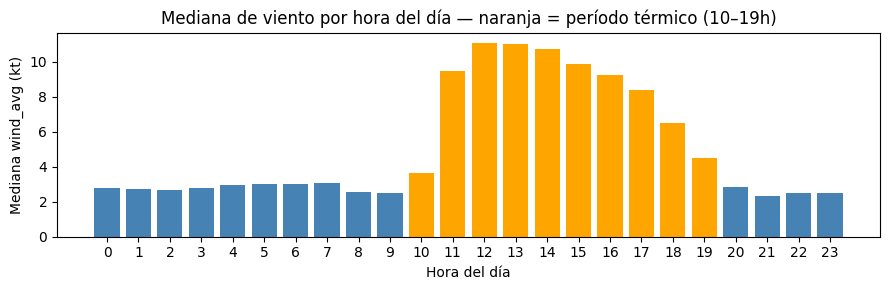

In [153]:
import matplotlib.pyplot as plt

hourly = df["wind_avg"].dropna().groupby(df["wind_avg"].dropna().index.hour).median()

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(
    hourly.index,
    hourly.values,
    color=["orange" if 10 <= h <= 19 else "steelblue" for h in hourly.index],
)
ax.set_xlabel("Hora del día")
ax.set_ylabel("Mediana wind_avg (kt)")
ax.set_title("Mediana de viento por hora del día — naranja = período térmico (10–19h)")
ax.set_xticks(range(24))
plt.tight_layout()

El aumento fuerte del viento aparece entre las 10 y las 19 horas, con el pico entre las 11 y las 16. Fuera de esa franja, las medianas son bastante parecidas. Con este criterio, un gap de más de 4 horas ya cubre una parte importante del período que más nos interesa pronosticar.

Ahora veamos cómo se reparten esos gaps.

In [154]:
is_nan = df["wind_avg"].isna()
gid = (~is_nan).cumsum()
durations = [
    int((g.index[-1] - g.index[0]).total_seconds() / 3600) + 1
    for _, g in df["wind_avg"][is_nan].groupby(gid[is_nan])
]

gaps_df = pd.DataFrame({"duration_h": durations})
total_gap_h = gaps_df["duration_h"].sum()

bins = [0, 1, 2, 3, 12, 24, 9999]
labels = ["1h", "2h", "3h", "4-12h", "13-24h", ">24h"]
gaps_df["bin"] = pd.cut(gaps_df["duration_h"], bins=bins, labels=labels)

dist = gaps_df.groupby("bin", observed=True)["duration_h"].agg(
    n_gaps="count", horas_total="sum"
)
dist["pct_gaps"] = (dist["horas_total"] / total_gap_h * 100).round(1)

print(f"Total gaps: {len(gaps_df)}")
print(f"Horas offline: {total_gap_h} ({100*total_gap_h/len(df):.1f}% de la serie)")
dist

Total gaps: 12
Horas offline: 276 (4.5% de la serie)


,n_gaps,horas_total,pct_gaps
bin,,,
1h,4,4,1.4
2h,1,2,0.7
3h,1,3,1.1
4-12h,1,8,2.9
13-24h,1,23,8.3
>24h,4,236,85.5


La tabla distribuye horas offline, no solo cantidad de gaps. Hay 12 gaps en total y, por cantidad, 6 duran más de 4 horas. Pero, medidos en horas perdidas, esos gaps concentran 96,7% del tiempo offline. Los gaps de hasta 3 horas suman solo 9 horas en total. Con este panorama, preferimos no imputar y trabajar sin completar observaciones faltantes.

### 4.d) Tipos de datos, variables endógenas y exógenas

In [155]:
df.dtypes

wind_avg          float64
wind_max          float64
temperature       float64
rh                float64
mslp              float64
wind_direction    float64
gustiness         float64
interval          float32
time_diff         float32
dtype: object

Las variables meteorológicas quedan como `float64`, mientras que `interval` y `time_diff` son columnas auxiliares `float32`. En todos los casos se trata de variables numéricas continuas.

Para el pronóstico, la variable endógena es `wind_avg`, porque es la que buscamos predecir a partir de su propia dinámica. Las demás (`wind_max`, `wind_direction`, `interval`, `temperature`, `rh`, `mslp`) quedan como variables exógenas posibles. Las variable `gustiness` no agrega información, ya que es un producto de la combinación de `wind_avg` y `wind_max`, por lo tanto, la quitaremos en el punto 5. A su vez, aplicamos el mismo criterio para `time_diff`.

### 4.e) Descomposición estacional

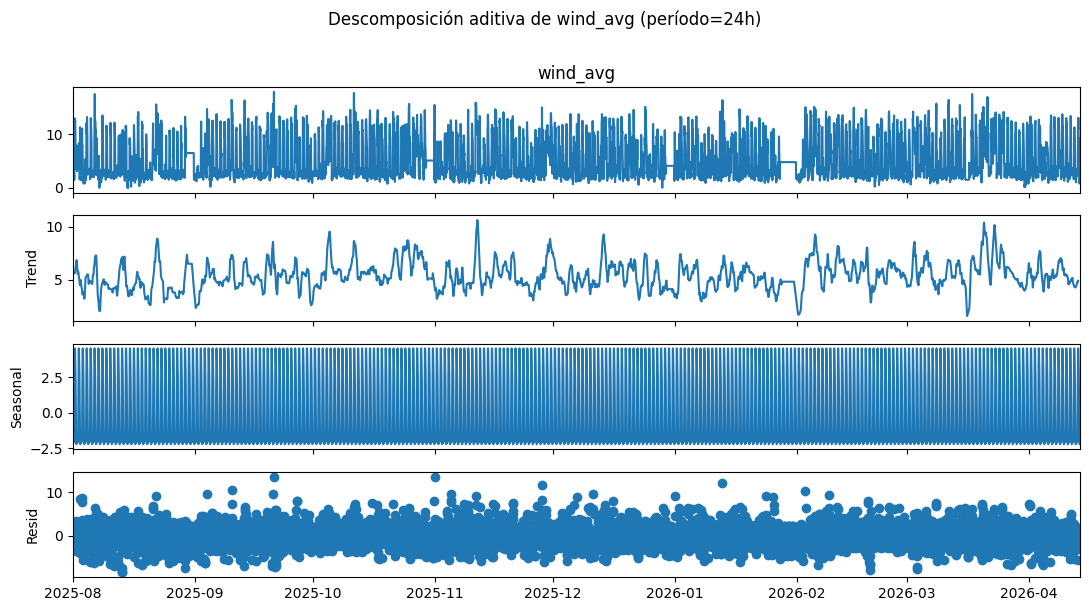

In [156]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

wind_filled = df["wind_avg"].ffill().bfill()

sd = seasonal_decompose(wind_filled, model="additive", period=24, extrapolate_trend=0)
fig = sd.plot()
fig.set_size_inches(11, 6)
plt.suptitle("Descomposición aditiva de wind_avg (período=24h)", y=1.01)
plt.tight_layout()

La descomposición revela una estacionalidad diaria clara y estable. La componente de tendencia no presenta un cambio sostenido a lo largo del año, sino que muestra fluctuaciones alrededor de una media constante. Es por esto que estos resultados nos dan indicio de que la serie es estacionaria.

### 4.f) Estacionariedad y extracción de residuos estacionarios

In [157]:
from statsmodels.tsa.stattools import adfuller

period = 24

print("--- Serie original (wind_avg) ---")
ADF_result = adfuller(df["wind_avg"].dropna())
print(f"ADF Statistic: {ADF_result[0]:.3f}")
print(f"p-value: {ADF_result[1]:.3e}")
print("Critical Values:")
for key, value in ADF_result[4].items():
    print(f"   {key}: {value:.3f}")

print()

print("--- Residuo de la descomposición ---")
ADF_result = adfuller(sd.resid[period:-period].dropna())
print(f"ADF Statistic: {ADF_result[0]:.3f}")
print(f"p-value: {ADF_result[1]:.3e}")
print("Critical Values:")
for key, value in ADF_result[4].items():
    print(f"   {key}: {value:.3f}")

--- Serie original (wind_avg) ---
ADF Statistic: -11.403
p-value: 7.578e-21
Critical Values:
   1%: -3.431
   5%: -2.862
   10%: -2.567

--- Residuo de la descomposición ---
ADF Statistic: -23.338
p-value: 0.000e+00
Critical Values:
   1%: -3.431
   5%: -2.862
   10%: -2.567


La prueba ADF evalúa:

- **H₀**: la serie tiene raíz unitaria, es decir, no es estacionaria por raíz unitaria.
- **H₁**: la serie es estacionaria.

Al obtener un p-valor de cero en ambas pruebas (inferior al umbral de 0.05), contamos con evidencia suficiente para rechazar la hipótesis nula, confirmando que las series no tienen raíces unitarias y son estacionarias. Esta conclusión se refuerza porque los estadísticos ADF de -11 y -23 son mucho más negativos que el valor crítico de -3.431, lo que sitúa a los datos muy lejos de la inestabilidad y garantiza que son aptos para el modelado.

### 4.g) Autocorrelación y autocorrelacion parcial

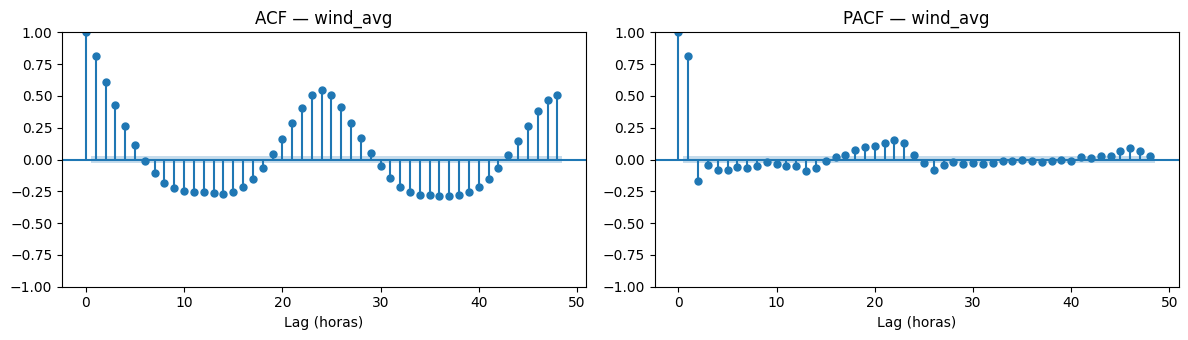

In [158]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

plot_acf(df["wind_avg"].dropna(), lags=48, bartlett_confint=False, ax=axes[0])
axes[0].set_title("ACF — wind_avg")
axes[0].set_xlabel("Lag (horas)")

plot_pacf(df["wind_avg"].dropna(), lags=48, ax=axes[1])
axes[1].set_title("PACF — wind_avg")
axes[1].set_xlabel("Lag (horas)")

plt.tight_layout()

Al analizar el ACF, se observan claramente los ciclos diarios del viento. El **lag 24** muestra una autocorrelación positiva de **0.5**, lo que indica que el patrón de ayer a esta hora tiende a repetirse hoy, explicando un **25% ($0.5^{2}$)** de la variabilidad actual. Por el contrario, el **lag 12** presenta una autocorrelación negativa, reflejando un efecto de "espejo" entre el día y la noche, es decir, si ahora el viento supera la media, en 12 horas es muy probable que esté por debajo de ella. Esta oscilación confirma que la serie es altamente cíclica y predecible según el horario.

El gráfico PACF revela que el viento solo tiene una relación directa con lo que pasó hace una o dos horas. Al eliminar el efecto de los pasos intermedios, vemos que casi toda la información relevante se agota en los primeros dos lags. Esto significa que, aunque en el ACF veas ciclos largos de 24 horas, para predecir el viento de ahora lo único que realmente aporta información nueva es el dato de las últimas dos horas, y también entre las útlimas 20 y 24 horas.

### 4.h) Período entre registros y espectro de potencias

Período entre registros: 1 hora (Δt = 1h). Nyquist: 12 ciclos/día.
Varianza: 14.0578  |  Parseval: 14.0578


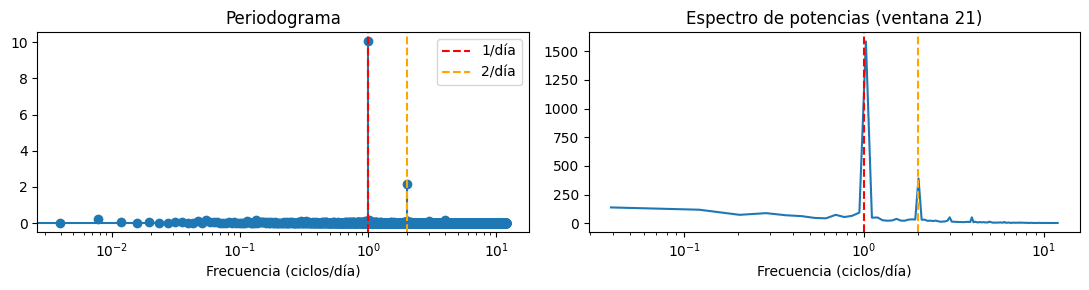

In [159]:
import numpy as np
import matplotlib.pyplot as plt

wind_filled = df["wind_avg"].ffill().bfill()
wind_centered = wind_filled - wind_filled.mean()
NT = len(wind_centered)

wind_f = np.fft.rfft(wind_centered.values)
armonics = np.arange(0, len(wind_f))
wind_f_adj = wind_f * 2 / NT
sqamp = np.real(wind_f_adj) ** 2 + np.imag(wind_f_adj) ** 2

print(f"Período entre registros: 1 hora (Δt = 1h). Nyquist: 12 ciclos/día.")
print(f"Varianza: {np.var(wind_centered):.4f}  |  Parseval: {0.5*np.sum(sqamp):.4f}")

freqs_per_day = armonics * 24 / NT

mw = 10
weights = np.ones(2 * mw + 1)
ps = 0.5 * np.convolve(NT * sqamp, weights, mode="same") / (2 * mw + 1)
ps = ps[mw :: 2 * mw + 1]
fs = armonics[mw :: 2 * mw + 1] * 24 / NT

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].stem(freqs_per_day, sqamp, markerfmt="C0o", basefmt="C0-", linefmt="C0-")
axes[0].set_xscale("log")
axes[0].set_xlabel("Frecuencia (ciclos/día)")
axes[0].set_title("Periodograma")
axes[0].axvline(x=1, color="r", linestyle="--", label="1/día")
axes[0].axvline(x=2, color="orange", linestyle="--", label="2/día")
axes[0].legend(loc="upper right")

axes[1].plot(fs, ps)
axes[1].set_xscale("log")
axes[1].set_xlabel("Frecuencia (ciclos/día)")
axes[1].set_title(f"Espectro de potencias (ventana {2*mw+1})")
axes[1].axvline(x=1, color="r", linestyle="--")
axes[1].axvline(x=2, color="orange", linestyle="--")

plt.tight_layout()

Medimos cada 1 hora, por lo que necesitamos al menos 2 mediciones para detectar cualquier ciclo. Eso fija el límite máximo en 12 ciclos/día.

El eje x del espectro muestra frecuencia en ciclos/día, y el período de cada ciclo es su inverso. El pico dominante aparece en 1 ciclo/día, lo que equivale a un período de 24 horas. Un segundo pico, mucho más débil, aparece en 2 ciclos/día, equivalente a 12 horas. Prácticamente toda la variabilidad del viento se concentra en estos dos ritmos, siendo el de 24 horas el que domina.

## 5. Modelo de regresión

### Elección del modelo

El análisis exploratorio mostró que `wind_avg` es estacionaria, tiene un ciclo diario marcado y que la información directa se agota en los primeros 2 lags y en los lags 20–24 (PACF). A su vez, disponemos de variables exógenas (`temperature`, `rh`, `mslp`, `wind_direction`, `wind_max`, `interval`) que pueden enriquecer la predicción.

Elegimos **Lasso** (regresión lineal con penalización L1) por las siguientes razones:

**1. Selección automática de atributos.** La penalización L1 lleva a cero los coeficientes de variables que no aportan información. La matriz de atributos incluye 24 lags de `wind_avg`, 6 variables exógenas y 2 features cíclicas de hora, totalizando 32 columnas. No todos son igualmente informativos, pero Lasso identifica y retiene solo los atributos relevantes, descartando los intermedios.

**2. Elección del alpha óptimo con LassoCV.** En lugar de fijar el alpha a mano, usamos `LassoCV`, que prueba una grilla de 100 valores de alpha y elige el que minimiza el error en validación cruzada. Esto garantiza que la penalización aplicada sea la adecuada para los datos y no una decisión arbitraria.

**3. Codificación cíclica de la hora.** El ciclo diario no es lineal, la hora 23 está a 1 hora de la hora 0, pero numéricamente parecen muy distintas. Para que el modelo capture correctamente esa continuidad, codificamos la hora del día con sus proyecciones seno y coseno:

$$\text{hora\_sin} = \sin\!\left(\frac{2\pi \cdot h}{24}\right), \quad \text{hora\_cos} = \cos\!\left(\frac{2\pi \cdot h}{24}\right)$$

### Baseline de comparación

Como modelo baseline usamos la **persistencia estacional**. Predice el viento de `h` horas en el futuro con el valor observado 24 horas atrás en el mismo punto (es decir, `wind_avg` del día anterior a la misma hora). Este baseline es razonable dado el ciclo diario fuerte observado en el ACF. Si el modelo no supera esta persistencia, no justifica su complejidad adicional.

In [160]:
df.drop(columns=["gustiness", "time_diff"], inplace=True)

In [161]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


class LagFeatures(TransformerMixin, BaseEstimator):
    def __init__(self, lags=1):
        self.lags = lags

    def fit(self, X, y=None):
        self.X_mean = X.mean()
        return self

    def transform(self, X):
        X_lagged = pd.DataFrame([])
        cols_to_lag = X.columns
        for col in cols_to_lag:
            for lag in range(1, self.lags + 1):
                fill_value = self.X_mean[col]
                new_series = X[col].shift(lag, fill_value=fill_value)
                X_lagged = pd.concat([X_lagged, new_series], axis=1)
                X_lagged = X_lagged.rename(
                    columns={X_lagged.columns[-1]: col + "_Lag_" + str(lag)}
                )
        return X_lagged

In [162]:
HORIZONTE = 12
N_LAGS = 24
N_SPLITS = 3
ALPHAS_GRID = np.logspace(-4, 1, 100)

y = df["wind_avg"]
X_exog = df.drop(columns=["wind_avg"])

lasso_cv = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "modelo",
            LassoCV(
                cv=TimeSeriesSplit(n_splits=3),
                max_iter=20000,
                n_jobs=-1,
                alphas=ALPHAS_GRID,
            ),
        ),
    ]
)


def crear_dataset(serie_objetivo, serie_features, horizonte, n_lags=N_LAGS):
    X_lags = LagFeatures(lags=n_lags).fit_transform(serie_objetivo.to_frame())
    X = pd.concat([serie_features, X_lags], axis=1)
    X["hora_sin"] = np.sin(2 * np.pi * X.index.hour / 24)
    X["hora_cos"] = np.cos(2 * np.pi * X.index.hour / 24)
    y = serie_objetivo.shift(-horizonte).rename("objetivo")
    y_base = serie_objetivo.shift(24 - horizonte).rename("persistencia")
    return pd.concat([X, y, y_base], axis=1).dropna()


def evaluar(serie_objetivo, serie_features, n_folds=N_SPLITS):
    filas = []
    cv = TimeSeriesSplit(n_splits=n_folds, gap=HORIZONTE)

    for h in range(1, HORIZONTE + 1):
        datos = crear_dataset(serie_objetivo, serie_features, h)
        X = datos.drop(columns=["objetivo", "persistencia"])
        y = datos["objetivo"]
        y_base = datos["persistencia"]

        for fold, (idx_train, idx_test) in enumerate(cv.split(X), start=1):
            X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
            y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]
            pred_base = y_base.iloc[idx_test].to_numpy()

            filas.append(
                {
                    "modelo": "Persistencia estacional",
                    "split": "test",
                    "horizonte": h,
                    "fold": fold,
                    "mae": mean_absolute_error(y_test, pred_base),
                    "rmse": np.sqrt(mean_squared_error(y_test, pred_base)),
                    "r2": r2_score(y_test, pred_base),
                }
            )

            modelo = lasso_cv

            modelo.fit(X_train, y_train)
            pred_train = modelo.predict(X_train)
            pred_test = modelo.predict(X_test)

            filas.append(
                {
                    "modelo": "LassoCV",
                    "split": "train",
                    "horizonte": h,
                    "fold": fold,
                    "mae": mean_absolute_error(y_train, pred_train),
                    "rmse": np.sqrt(mean_squared_error(y_train, pred_train)),
                    "r2": r2_score(y_train, pred_train),
                }
            )

            filas.append(
                {
                    "modelo": "LassoCV",
                    "split": "test",
                    "horizonte": h,
                    "fold": fold,
                    "mae": mean_absolute_error(y_test, pred_test),
                    "rmse": np.sqrt(mean_squared_error(y_test, pred_test)),
                    "r2": r2_score(y_test, pred_test),
                }
            )

    return pd.DataFrame(filas)


resultados = evaluar(y, X_exog)
resultados_test = resultados[resultados["split"] == "test"]

modelos_a_mostrar = ["Persistencia estacional", "LassoCV"]

resumen = (
    resultados_test.groupby("modelo")[["mae", "rmse", "r2"]]
    .mean()
    .round(3)
    .loc[modelos_a_mostrar]
)
rmse_base = resumen.loc["Persistencia estacional", "rmse"]
resumen["mejora_%"] = ((1 - resumen["rmse"] / rmse_base) * 100).round(1)

display(
    resumen.rename(
        columns={"mae": "MAE", "rmse": "RMSE", "r2": "R²", "mejora_%": "Mejora %"}
    )
)

,MAE,RMSE,R²,Mejora %
modelo,,,,
Persistencia estacional,2.544,3.589,0.117,0.0
LassoCV,2.069,2.704,0.498,24.7


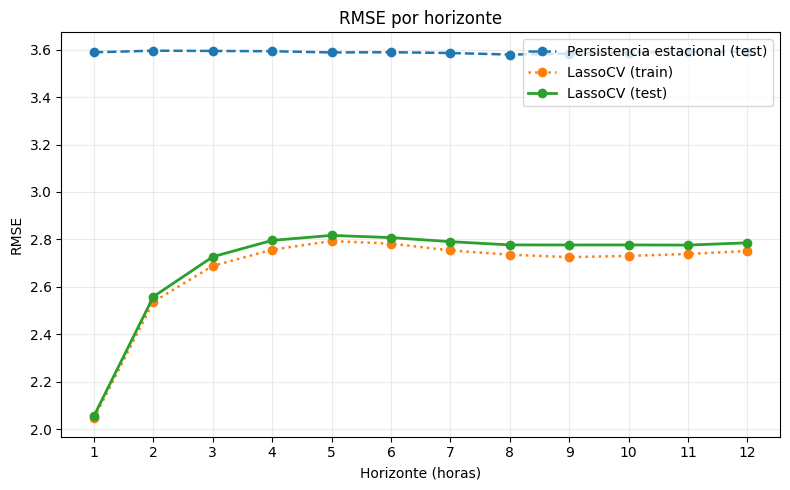

In [163]:
fig, axes = plt.subplots(figsize=(8, 5))

horizontes = range(1, HORIZONTE + 1)

rmse_lasso_train = (
    resultados[(resultados["modelo"] == "LassoCV") & (resultados["split"] == "train")]
    .groupby("horizonte")["rmse"]
    .mean()
    .reindex(horizontes)
)

rmse_lasso_test = (
    resultados[(resultados["modelo"] == "LassoCV") & (resultados["split"] == "test")]
    .groupby("horizonte")["rmse"]
    .mean()
    .reindex(horizontes)
)

rmse_base_test = (
    resultados[
        (resultados["modelo"] == "Persistencia estacional")
        & (resultados["split"] == "test")
    ]
    .groupby("horizonte")["rmse"]
    .mean()
    .reindex(horizontes)
)

axes.plot(
    list(horizontes),
    rmse_base_test.values,
    marker="o",
    linestyle="--",
    linewidth=1.8,
    label="Persistencia estacional (test)",
)

axes.plot(
    list(horizontes),
    rmse_lasso_train.values,
    marker="o",
    linestyle=":",
    linewidth=1.8,
    label="LassoCV (train)",
)

axes.plot(
    list(horizontes),
    rmse_lasso_test.values,
    marker="o",
    linestyle="-",
    linewidth=2.0,
    label="LassoCV (test)",
)

axes.set_title("RMSE por horizonte")
axes.set_xlabel("Horizonte (horas)")
axes.set_ylabel("RMSE")
axes.set_xticks(range(1, HORIZONTE + 1))
axes.legend(loc="upper right")
axes.grid(alpha=0.25)
plt.tight_layout()

### Resultados

LassoCV reduce el RMSE promedio de 3.589 a 2.704 nudos, una mejora del 24.7% respecto a la persistencia estacional. El R² sube de 0.117 a 0.498, lo que indica que el modelo explica casi la mitad de la varianza del viento futuro, contra un 12% del baseline. Esta ganancia se mantiene en todos los horizontes. A su vezs, en el gráfico, la curva de test de LassoCV se ubica consistentemente por debajo de la persistencia estacional para cada una de las 12 horas pronosticadas. Es importante destacar que las curvas de RMSE en train y en test son muy próximas entre sí a lo largo de todos los horizontes, indicando bajos indicios de overfitting.